In [1]:
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt

# 1.) Create LCG random number generator

In [133]:
def LCG(a,c, M, N, seed=42):
    # Allocate memory
    arr = np.empty(N, dtype=np.float64)
    arr[0] = seed % M

    # Loop
    for i in range(1,N):
        arr[i] = (a*arr[i-1] + c) % M
    
    return arr/M
        
def plot_run(a, c, M, N, seed, arr, n_classes=None):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    fig.suptitle(
        f"LCG Parameters: a={a}, c={c}, M={M}, N={N}, seed={seed}",
        fontsize=14
    )

    # Histogram
    counts, bin_edges, _ = axs[0].hist(
        arr,
        bins=n_classes,
        edgecolor="black"
    )
    axs[0].set_title("Histogram",fontsize=16)
    axs[0].set_xlabel("Value",fontsize=14)
    axs[0].set_ylabel("Frequency",fontsize=14)

    # Sequence plot
    axs[1].plot(np.arange(len(arr)), arr, ".", markersize=1)
    axs[1].set_title("Sequence",fontsize=16)
    axs[1].set_xlabel("n",fontsize=14)
    axs[1].set_ylabel("xₙ",fontsize=14)

    # Lag-1 scatter plot
    axs[2].plot(arr[:-1], arr[1:], ".", markersize=1)
    axs[2].set_title("Lag Plot",fontsize=16)
    axs[2].set_xlabel("$x_n$",fontsize=14)
    axs[2].set_ylabel("$x_{n+1}$",fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    return counts, bin_edges

## a)

In [134]:
a = 5
c = 1
M = 16
N = 10_000
seed = 30

arr1 = LCG(a,c,M,N, seed=seed)

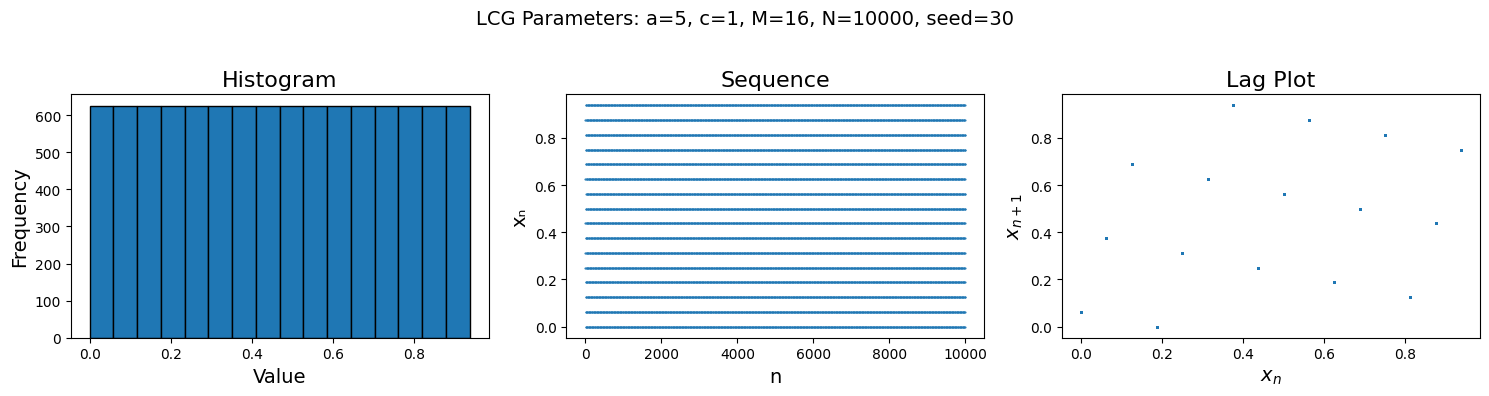

In [135]:
counts, bin_edges= plot_run(a,c,M,N,seed,arr1,n_classes=M)

### $\chi^2$-test

$$
    T = \sum \frac{(observed-expected)^2}{expected}
$$

In [136]:
def chisq_test(counts,N):
    T = 0
    n_classes = len(counts)
    for i in range(n_classes):
        n_expected = N*1/n_classes
        n_observed = counts[i]
        T += (n_observed-n_expected)**2 / n_expected

    p_val = 1-ss.chi2.cdf(T,df=n_classes-1)
    return p_val

chisq_test(counts,N)

np.float64(1.0)

### Run test 1

In [137]:
def run_test_1(x):
    m = np.median(x)
    n1 = np.sum(x > m)
    n2 = np.sum(x <= m)

    # loc = 2 * n1*n2 / (n1+n2) + 1
    # scale = 2 * n1*n2 * (2*n1*n2-n1-n2) / ((n1+n2)^2 * (n1+n2-1))
    # t = np.linspace(loc-4*scale, loc+4*scale, 1000)
    # normal = ss.norm.pdf(t, loc, scale)
    # plt.plot(t, normal)

    mu_T = 2 * n1*n2 / (n1+n2) + 1 # Mean, or Expected number of runs
    sig_T = np.sqrt(2 * n1*n2 * (2*n1*n2-n1-n2) / ((n1+n2)**2 * (n1+n2-1))) # Variance

    s = (x > m) # Number of runs above the median

    T = 1 + np.sum(s[1:] != s[:-1]) # Compare adjacent elements to obtain T
    print('Total number of runs: T =', T)

    Z = (T - mu_T) / sig_T # Measure how far we are from what we expect
    print('Comparison with the theory: Z =', Z)

    print(f"pval: {2*(1-ss.norm.cdf(abs(Z)))}")

    return(T,Z)

### Smirmov test

In [138]:
F = lambda x: np.clip(x, 0, 1)  # uniform fordeling 

def smirnov(data, CDF):
    data_sorted = np.sort(data)
    p = np.arange(len(data)) / (len(data) - 1)   # empirical CDF
    p_cdf = CDF(data_sorted)                      # theoretical CDF
    D = np.max(np.abs(p - p_cdf))                 # sup
    return D

### c)

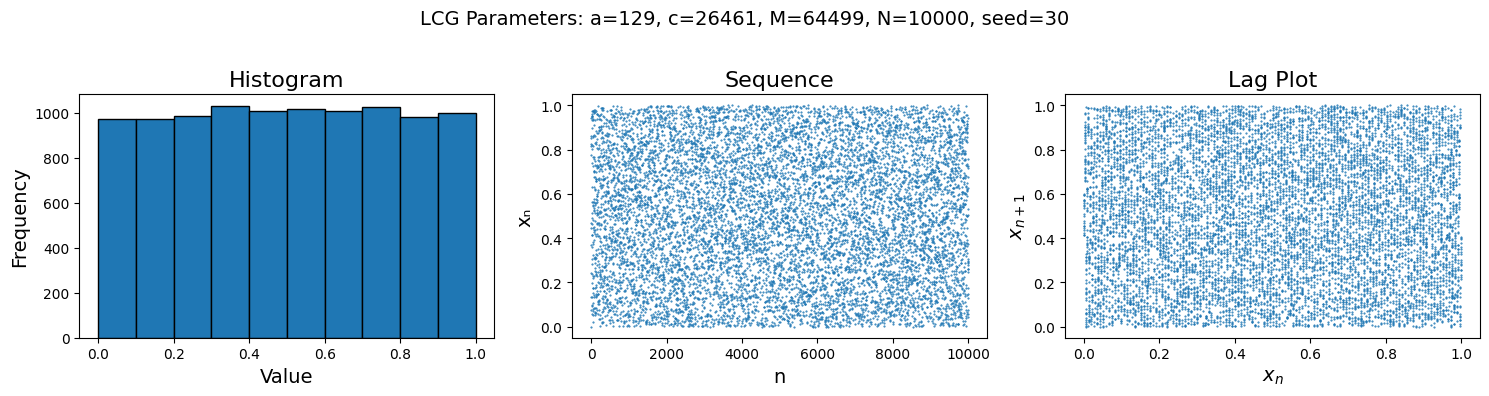

Tests:
Chisq-test: 0.9091604978534507

Run test
Total number of runs: T = 4958
Comparison with the theory: Z = -0.8600430075263439
pval: 0.3897653356239932

Smirnov test: 0.008830252472835642


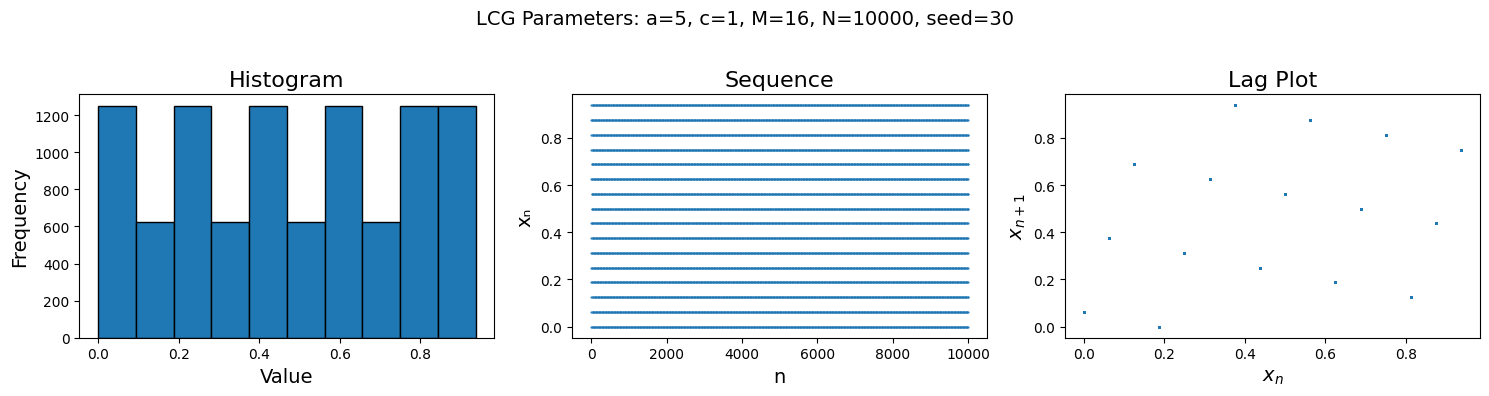

Tests:
Chisq-test: 0.0

Run test
Total number of runs: T = 3751
Comparison with the theory: Z = -25.001250218789068
pval: 0.0

Smirnov test: 0.0625


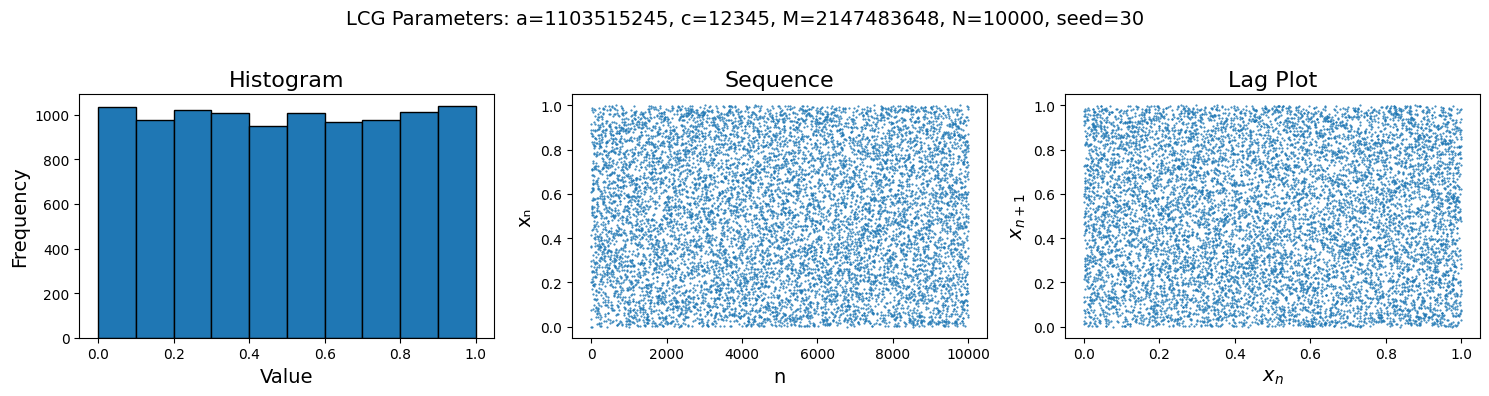

Tests:
Chisq-test: 0.5544204358728568

Run test
Total number of runs: T = 5030
Comparison with the theory: Z = 0.5800290050759064
pval: 0.5618950581019284

Smirnov test: 0.006693007767420989


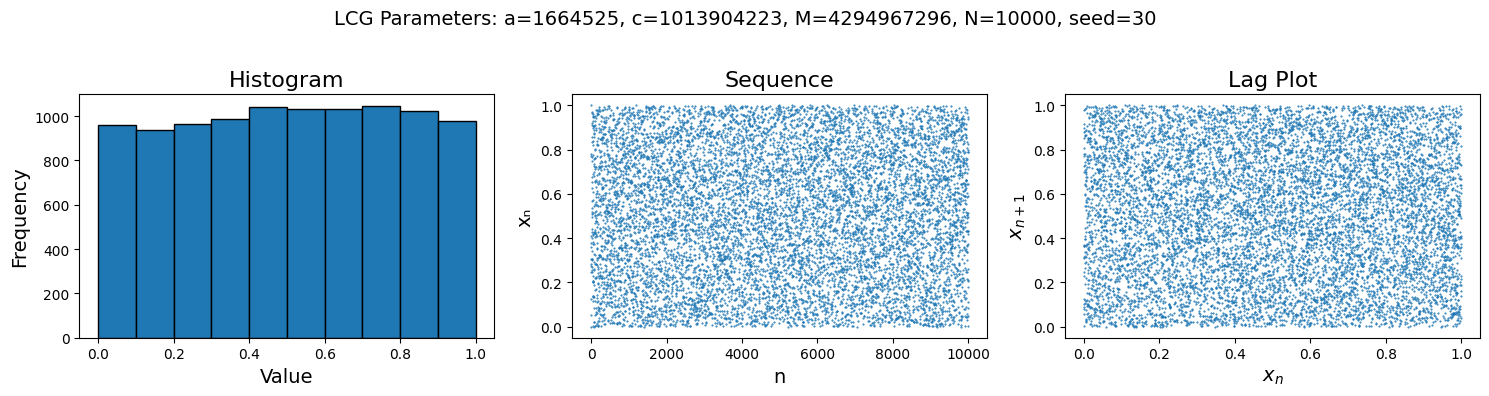

Tests:
Chisq-test: 0.14360470222845523

Run test
Total number of runs: T = 5050
Comparison with the theory: Z = 0.9800490085765314
pval: 0.327061927672712

Smirnov test: 0.01615895061475292


In [139]:
a = [129, 5, 1103515245, 1664525]
c = [26461, 1, 12345, 1013904223]
M = [64499, 16, 2**31, 2**32]
N = [10_000, 10_000, 10_000, 10_000]
seed = [30,30,30,30]

for i in range(4):
    arr = LCG(a[i],c[i],M[i],N[i], seed=seed[i])
    counts, bin_edges = plot_run(a[i],c[i],M[i],N[i],seed[i],arr)
    
    print("Tests:")
    print(f"Chisq-test: {chisq_test(counts,N[i])}")
    print("\nRun test")
    run_test_1(arr)
    print(f"\nSmirnov test: {smirnov(arr, F)}")



# 2. Apply a system available generator

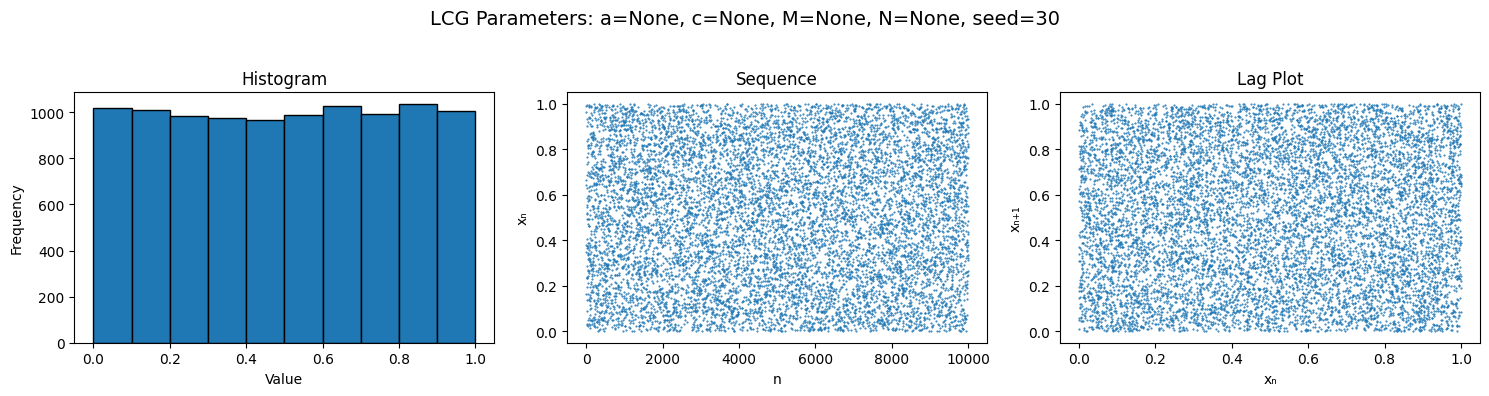

Tests:
Chisq-test: 0.8510483670629825

Run test
Total number of runs: T = 4912
Comparison with the theory: Z = -0.0002919383414336661

Smirnov test: 0.007984710126879624


In [98]:
np.random.seed(30)
arr2 = np.random.uniform(size=10_000)
counts, bin_edges = plot_run("None","None","None","None",30,arr2,n_classes=10)

print("Tests:")
print(f"Chisq-test: {chisq_test(counts,10_000)}")
print("\nRun test")
run_test_1(arr2)
print(f"\nSmirnov test: {smirnov(arr2, F)}")

# 3. You were asked to simulate one sample and perform tests on this sample. Discuss the sufficiency of this approach and take action, if needed.

In [112]:
P_VALS = []
for i in range(1_00000):
    arr = LCG(a[0],c[0],M[0],N[0], seed=i)
    counts, bin_edges = np.histogram(arr, bins=10)
    
    P_VALS.append(chisq_test(counts,N[0]))

(array([1.0000e+00, 1.4020e+03, 3.7890e+03, 6.6560e+03, 1.0986e+04,
        1.2906e+04, 1.6424e+04, 1.9552e+04, 1.8930e+04, 9.3540e+03]),
 array([0.        , 0.09770599, 0.19541198, 0.29311798, 0.39082397,
        0.48852996, 0.58623595, 0.68394195, 0.78164794, 0.87935393,
        0.97705992]),
 <BarContainer object of 10 artists>)

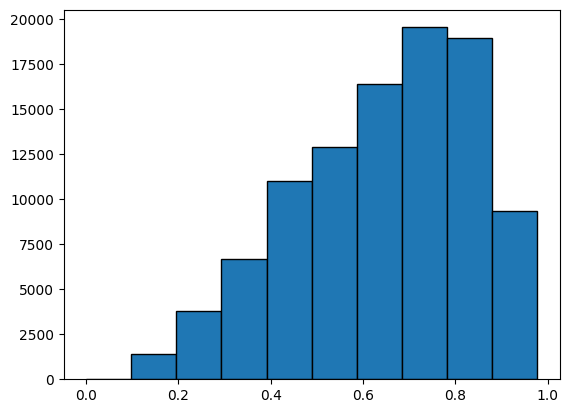

In [114]:
plt.hist(P_VALS, edgecolor="black")